In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [4]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [5]:
df=pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target']=y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-1.828081,-0.096580,1.776290,-1.684891,1.410970,0
1,-1.899110,0.317782,1.188163,-2.037107,2.145524,0
2,4.649168,0.855735,-2.870612,-1.162393,1.378168,1
3,-0.480267,0.963119,1.954244,0.435585,0.801764,0
4,-2.313682,1.091875,0.385786,-0.746716,-0.115521,0


In [7]:
#function for row sampling

def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [14]:
# function for feature sampling
import random
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols].copy()
  new_df['target'] = df['target']
  return new_df

In [15]:
#function for combind sampling
def combined_sampling(df,row_percent,col_percent):
    new_df=sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

In [16]:
df1=combined_sampling(df,0.5,0.5)

In [17]:
df2= combined_sampling(df,0.5,0.5)

In [18]:
df3=combined_sampling(df,0.5,0.5)

In [19]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col4', 'target'], dtype='object')
Index(['col1', 'col5', 'target'], dtype='object')
Index(['col5', 'col4', 'target'], dtype='object')


In [20]:
df3

,col5,col4,target
42,0.259055,0.387412,1
4,-0.115521,-0.746716,0
70,3.041547,-3.899608,0
44,1.242821,-0.824162,1
59,1.422095,-0.724407,1
25,1.406888,0.606516,1
94,-0.677462,0.112012,0
98,0.755321,-0.347214,0
5,2.067629,-0.655150,0
75,1.462382,-0.723270,0


In [21]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [22]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [23]:
from sklearn.tree import plot_tree

[Text(0.45588235294117646, 0.95, 'x[1] <= 1.391\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.39705882352941174, 0.85, 'x[1] <= 0.138\ngini = 0.499\nsamples = 48\nvalue = [23, 25]'),
 Text(0.4264705882352941, 0.8999999999999999, 'True  '),
 Text(0.3382352941176471, 0.75, 'x[0] <= 0.67\ngini = 0.498\nsamples = 43\nvalue = [23.0, 20.0]'),
 Text(0.11764705882352941, 0.65, 'x[1] <= -0.941\ngini = 0.397\nsamples = 11\nvalue = [3, 8]'),
 Text(0.058823529411764705, 0.55, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.17647058823529413, 0.55, 'x[0] <= 0.259\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.11764705882352941, 0.45, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.23529411764705882, 0.45, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.5588235294117647, 0.65, 'x[0] <= 1.112\ngini = 0.469\nsamples = 32\nvalue = [20, 12]'),
 Text(0.4117647058823529, 0.55, 'x[1] <= -1.583\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.35294117647058826, 0.45, 'x[0] <

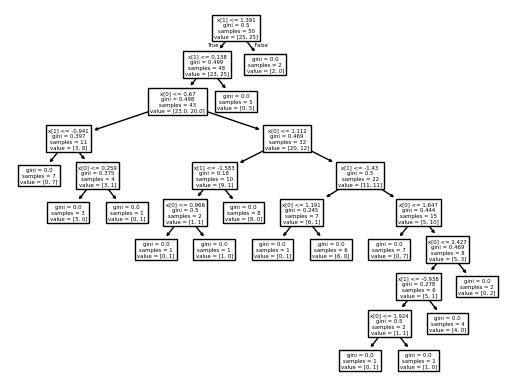

In [24]:
plot_tree(clf1)

[Text(0.375, 0.9375, 'x[0] <= -0.388\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.16666666666666666, 0.8125, 'x[0] <= -0.509\ngini = 0.1\nsamples = 19\nvalue = [18, 1]'),
 Text(0.2708333333333333, 0.875, 'True  '),
 Text(0.08333333333333333, 0.6875, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.25, 0.6875, 'x[0] <= -0.472\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.16666666666666666, 0.5625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.5625, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.5833333333333334, 0.8125, 'x[1] <= -0.822\ngini = 0.437\nsamples = 31\nvalue = [10, 21]'),
 Text(0.4791666666666667, 0.875, '  False'),
 Text(0.5, 0.6875, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6666666666666666, 0.6875, 'x[1] <= 2.067\ngini = 0.375\nsamples = 28\nvalue = [7, 21]'),
 Text(0.5, 0.5625, 'x[0] <= 0.998\ngini = 0.227\nsamples = 23\nvalue = [3, 20]'),
 Text(0.4166666666666667, 0.4375, 'x[0] <= 0.532\ngini = 0.355\

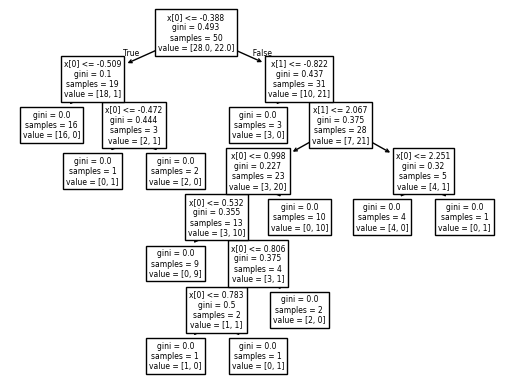

In [25]:
plot_tree(clf2)

[Text(0.3076923076923077, 0.9583333333333334, 'x[0] <= -0.334\ngini = 0.48\nsamples = 50\nvalue = [20, 30]'),
 Text(0.15384615384615385, 0.875, 'x[1] <= -2.204\ngini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.23076923076923078, 0.9166666666666667, 'True  '),
 Text(0.07692307692307693, 0.7916666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.23076923076923078, 0.7916666666666666, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.46153846153846156, 0.875, 'x[1] <= -2.445\ngini = 0.439\nsamples = 43\nvalue = [14.0, 29.0]'),
 Text(0.38461538461538464, 0.9166666666666667, '  False'),
 Text(0.38461538461538464, 0.7916666666666666, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.5384615384615384, 0.7916666666666666, 'x[1] <= -1.691\ngini = 0.381\nsamples = 39\nvalue = [10, 29]'),
 Text(0.46153846153846156, 0.7083333333333334, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.6153846153846154, 0.7083333333333334, 'x[1] <= 0.27\ngini = 0.452\nsamples = 29\nvalue = 

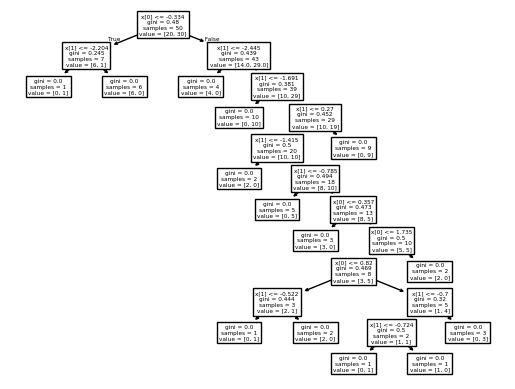

In [26]:
plot_tree(clf3)

In [33]:
clf1.predict(np.array([0.259055	,0.387412]).reshape(1,2))

D:\ML Engineer\jupyter_notebook\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [34]:
clf2.predict(np.array([-0.115521,-0.746716]).reshape(1,2))

D:\ML Engineer\jupyter_notebook\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [30]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

D:\ML Engineer\jupyter_notebook\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [31]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
62,-0.343515,-0.784011,-1.237351,0.170897,1.507995,1
9,-0.604900,1.811522,0.877315,-0.687934,1.810940,0
39,-1.214364,-1.321008,2.438048,-0.079802,0.081211,0
24,-0.457327,0.291876,1.120837,-1.649361,1.889381,0
82,-0.169287,-1.619450,-0.239007,-1.136160,0.510599,1
28,-2.189016,1.250026,1.197702,-0.166454,-0.678615,0
79,-0.980296,1.253697,1.441725,1.563720,-1.856128,0
94,-1.211936,0.116284,1.520312,0.112012,-0.677462,0
12,-0.224345,-1.192354,-1.155458,-0.383463,2.706170,1
89,3.707263,-0.068507,-2.261704,-2.065609,0.750241,1


In [35]:
df1

,col5,col4,target
22,0.845448,-1.708019,1
65,-0.966941,-2.678878,1
29,2.320599,-2.372726,0
78,3.056697,-1.374168,1
77,1.107097,-1.102894,0
2,1.378168,-1.162393,1
56,1.116965,-1.883581,1
77,1.107097,-1.102894,0
37,0.706055,-1.458080,0
93,0.844105,0.105260,0
